# Thesis Analysis Visualisation Notebook

This notebook reads the CSV files produced by `data_analysis/analysis.py` and generates thesis-ready charts.

Expected files in the working directory:
- `analysis_difficulty_stratification.csv`
- `analysis_oracle_by_difficulty.csv`
- `analysis_public_vote_correlation.csv`
- `analysis_agreement_conditioned.csv`
- `analysis_case_consistency.csv`
- `analysis_experiment_correlation.csv`
- `analysis_transition_*.csv`
- `analysis_calibration_*.csv`

Run this notebook from the same folder where those CSVs were generated, or update `OUTPUT_DIR` below.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path(".")
FIG_DIR = OUTPUT_DIR / "thesis_figures"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

def save_fig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()


## 1. Difficulty-stratified accuracy

This chart shows whether each experiment performs differently on easy, medium, and hard cases. Difficulty is based on public vote correctness:
- hard: public correctness ≤ 30%
- medium: 30% < public correctness ≤ 60%
- easy: public correctness > 60%


In [2]:
difficulty = pd.read_csv(OUTPUT_DIR / "analysis_difficulty_stratification.csv", index_col=0)
difficulty


,easy,medium,hard,all
experiment,,,,
Single_Agent_MedGemma-1.5-4B_689cases,59.40,46.29,18.18,47.02
Single_Agent_Qwen2.5VL-7B_689cases,67.67,46.48,13.64,48.48
lg_conditional_debate_689,69.92,49.02,15.91,50.94
lg_conservative_689,59.40,49.22,20.45,49.35
lg_describe_fuse_689,63.16,48.05,25.00,49.49
lg_directed_debate_689,57.89,44.53,20.45,45.57
lg_option_ranking_689,60.90,50.78,20.45,50.80
mode1_cot_689,58.65,37.89,22.73,40.93
mode1_qwen_vision_689,48.87,40.04,11.36,39.91


Saved: thesis_figures\difficulty_stratified_accuracy.png


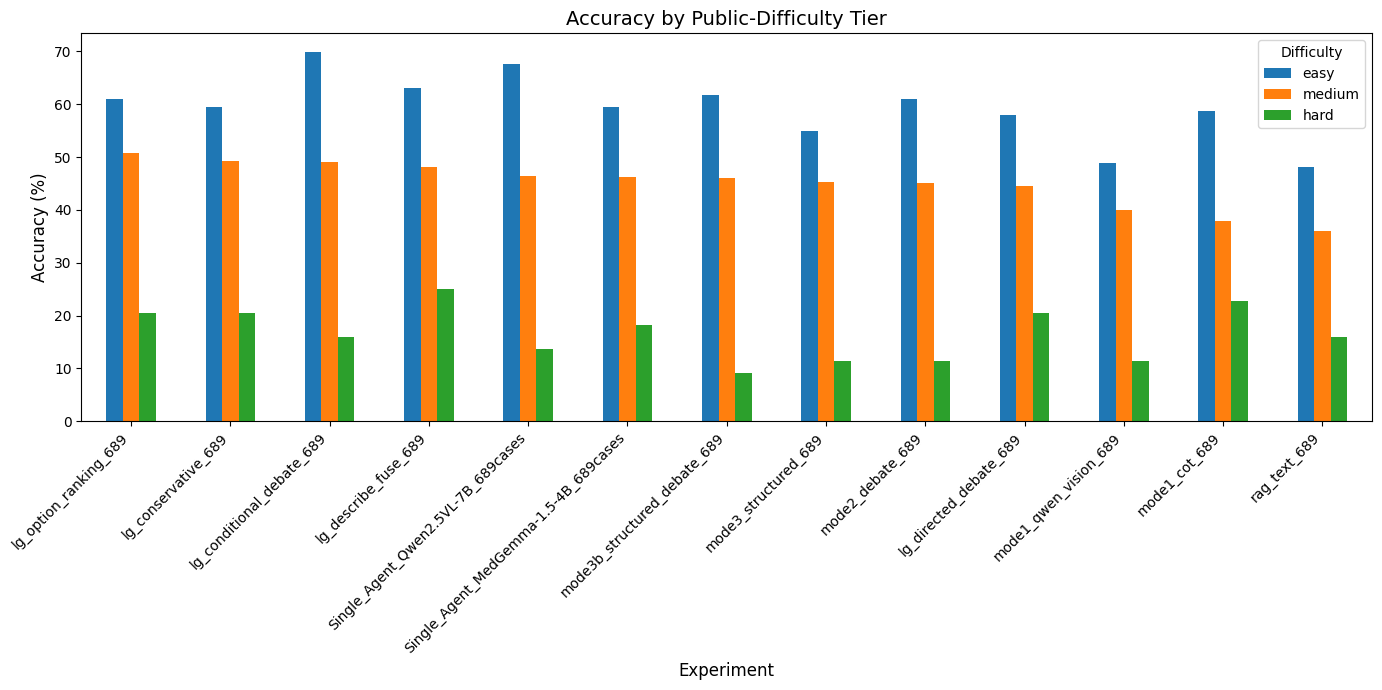

In [3]:
plot_df = difficulty[["easy", "medium", "hard"]].sort_values("medium", ascending=False)

ax = plot_df.plot(kind="bar", figsize=(14, 7))
ax.set_title("Accuracy by Public-Difficulty Tier")
ax.set_xlabel("Experiment")
ax.set_ylabel("Accuracy (%)")
ax.legend(title="Difficulty")
plt.xticks(rotation=45, ha="right")
save_fig("difficulty_stratified_accuracy.png")


## 2. Overall accuracy ranking

This is useful as a simple headline figure for the Results section.


Saved: thesis_figures\overall_accuracy_ranking.png


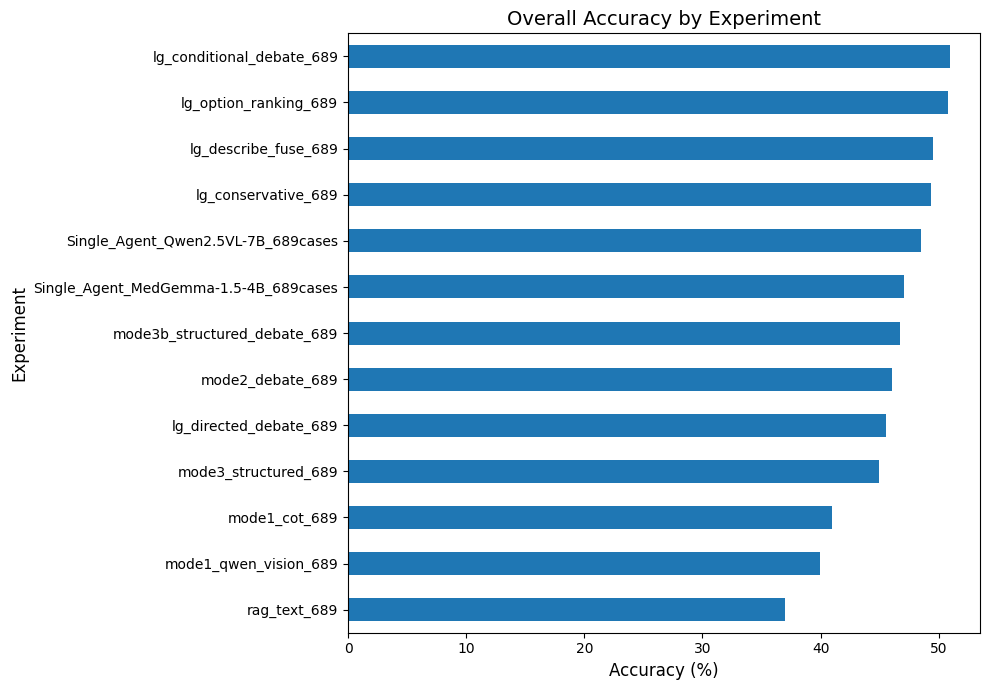

In [4]:
overall = difficulty[["all"]].dropna().sort_values("all", ascending=True)

ax = overall.plot(kind="barh", legend=False, figsize=(10, 7))
ax.set_title("Overall Accuracy by Experiment")
ax.set_xlabel("Accuracy (%)")
ax.set_ylabel("Experiment")
save_fig("overall_accuracy_ranking.png")


## 3. Oracle ceiling by difficulty

Oracle ceiling means the case is counted correct if either the text specialist or vision specialist was correct.


,easy,medium,hard,all
experiment,,,,
lg_conditional_debate_689,75.94,52.93,18.18,55.15
lg_option_ranking_689,70.68,62.70,31.82,62.26
mode1_cot_689,79.70,61.52,29.55,62.99
mode1_qwen_vision_689,76.69,66.41,20.45,65.46
mode3_structured_689,76.69,65.03,31.82,65.16
rag_text_689,75.19,57.81,27.27,59.22


Saved: thesis_figures\oracle_ceiling_by_difficulty.png


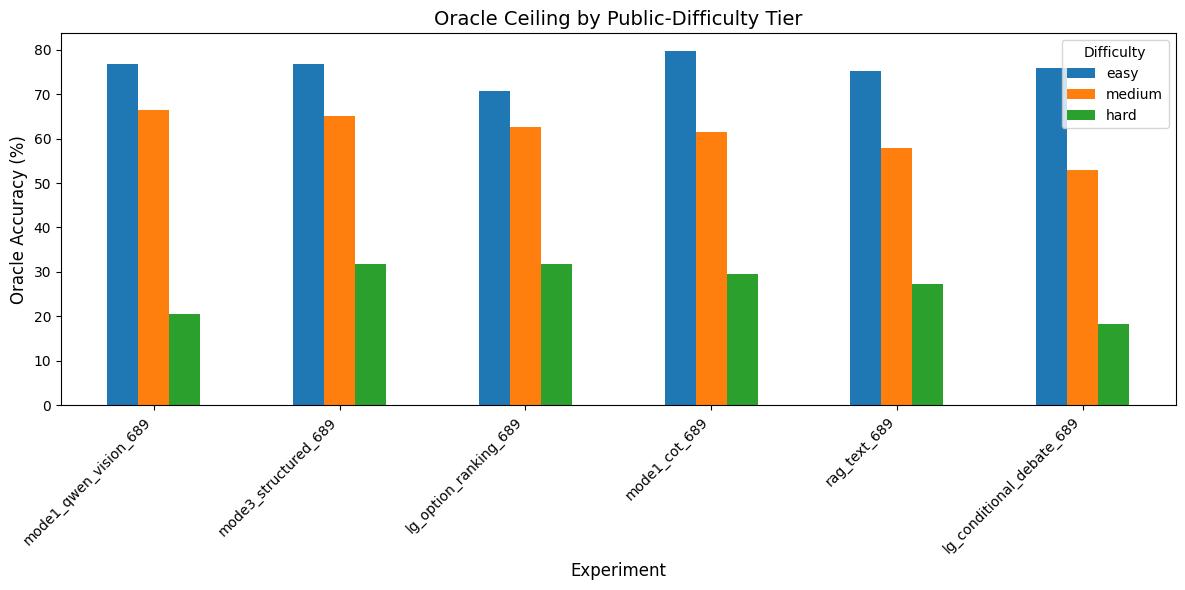

In [5]:
oracle_path = OUTPUT_DIR / "analysis_oracle_by_difficulty.csv"

if oracle_path.exists():
    oracle = pd.read_csv(oracle_path, index_col=0)
    display(oracle)

    plot_df = oracle[["easy", "medium", "hard"]].sort_values("medium", ascending=False)
    ax = plot_df.plot(kind="bar", figsize=(12, 6))
    ax.set_title("Oracle Ceiling by Public-Difficulty Tier")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Oracle Accuracy (%)")
    ax.legend(title="Difficulty")
    plt.xticks(rotation=45, ha="right")
    save_fig("oracle_ceiling_by_difficulty.png")
else:
    print("Oracle CSV not found.")


## 4. Public vote correlation

This shows how strongly each experiment's success aligns with human/public difficulty.
Higher positive correlation means the model tends to succeed on the same cases the public found easier.


,experiment,correlation_with_public,n
6,mode1_qwen_vision_689,0.1535,689
10,rag_text_689,0.1611,689
4,lg_option_ranking_689,0.1959,689
2,lg_describe_fuse_689,0.2043,689
3,lg_directed_debate_689,0.2072,689
5,mode1_cot_689,0.2094,689
8,mode3_structured_689,0.2117,686
1,lg_conservative_689,0.2155,689
11,Single_Agent_MedGemma-1.5-4B_689cases,0.2213,689
9,mode3b_structured_debate_689,0.2457,689


Saved: thesis_figures\public_vote_correlation.png


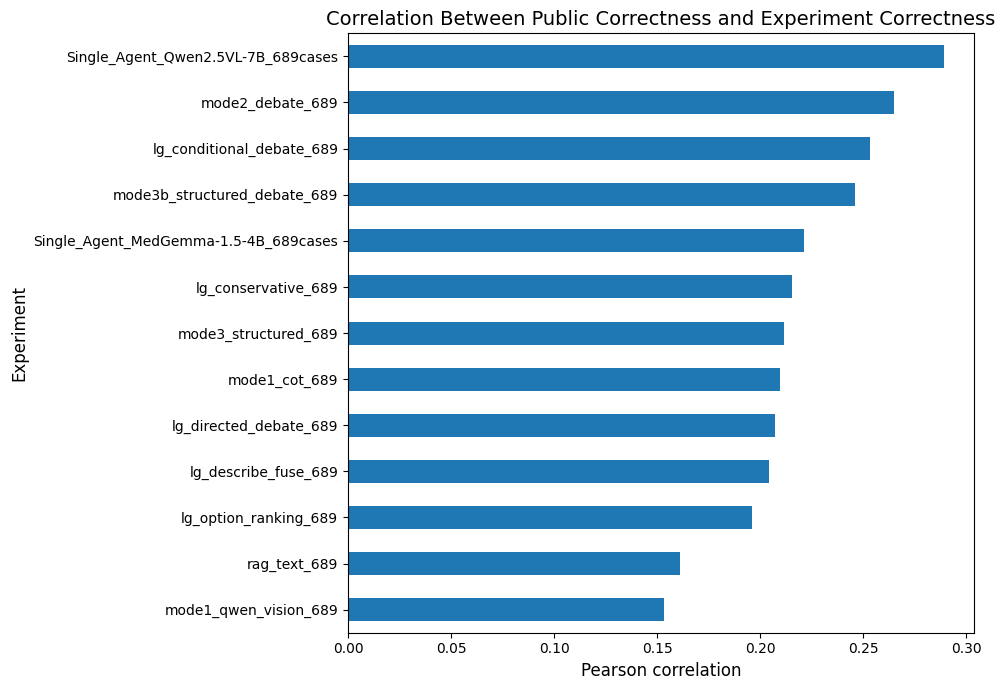

In [6]:
corr_path = OUTPUT_DIR / "analysis_public_vote_correlation.csv"

if corr_path.exists():
    corr = pd.read_csv(corr_path).sort_values("correlation_with_public", ascending=True)
    display(corr)

    ax = corr.plot(
        kind="barh",
        x="experiment",
        y="correlation_with_public",
        legend=False,
        figsize=(10, 7),
    )
    ax.set_title("Correlation Between Public Correctness and Experiment Correctness")
    ax.set_xlabel("Pearson correlation")
    ax.set_ylabel("Experiment")
    save_fig("public_vote_correlation.png")
else:
    print("Public vote correlation CSV not found.")


## 5. Cross-experiment consistency heatmap

This visualises whether experiments succeed and fail on the same cases.


,lg_conditional_debate_689,lg_conservative_689,lg_describe_fuse_689,lg_directed_debate_689,lg_option_ranking_689,mode1_cot_689,mode1_qwen_vision_689,mode2_debate_689,mode3_structured_689,mode3b_structured_debate_689,rag_text_689,Single_Agent_MedGemma-1.5-4B_689cases,Single_Agent_Qwen2.5VL-7B_689cases
lg_conditional_debate_689,1.000000,0.405288,0.431350,0.402451,0.404757,0.279518,0.224722,0.346651,0.315879,0.279091,0.223049,0.377766,0.359296
lg_conservative_689,0.405288,1.000000,0.439695,0.338372,0.408133,0.235225,0.238871,0.306201,0.297850,0.268248,0.211431,0.326389,0.285681
lg_describe_fuse_689,0.431350,0.439695,1.000000,0.411478,0.416783,0.303647,0.260208,0.361755,0.266037,0.294611,0.251284,0.364356,0.399025
lg_directed_debate_689,0.402451,0.338372,0.411478,1.000000,0.329309,0.234008,0.212284,0.295468,0.290926,0.264323,0.191862,0.328970,0.348614
lg_option_ranking_689,0.404757,0.408133,0.416783,0.329309,1.000000,0.211070,0.262645,0.349313,0.219209,0.293434,0.153110,0.235068,0.321432
mode1_cot_689,0.279518,0.235225,0.303647,0.234008,0.211070,1.000000,0.219673,0.350933,0.260862,0.267462,0.395117,0.363061,0.273444
mode1_qwen_vision_689,0.224722,0.238871,0.260208,0.212284,0.262645,0.219673,1.000000,0.252578,0.232883,0.198876,0.185508,0.194064,0.330255
mode2_debate_689,0.346651,0.306201,0.361755,0.295468,0.349313,0.350933,0.252578,1.000000,0.224286,0.244272,0.239304,0.384675,0.269961
mode3_structured_689,0.315879,0.297850,0.266037,0.290926,0.219209,0.260862,0.232883,0.224286,1.000000,0.263629,0.229800,0.281699,0.208490
mode3b_structured_debate_689,0.279091,0.268248,0.294611,0.264323,0.293434,0.267462,0.198876,0.244272,0.263629,1.000000,0.215853,0.277312,0.220644


Saved: thesis_figures\experiment_correlation_heatmap.png


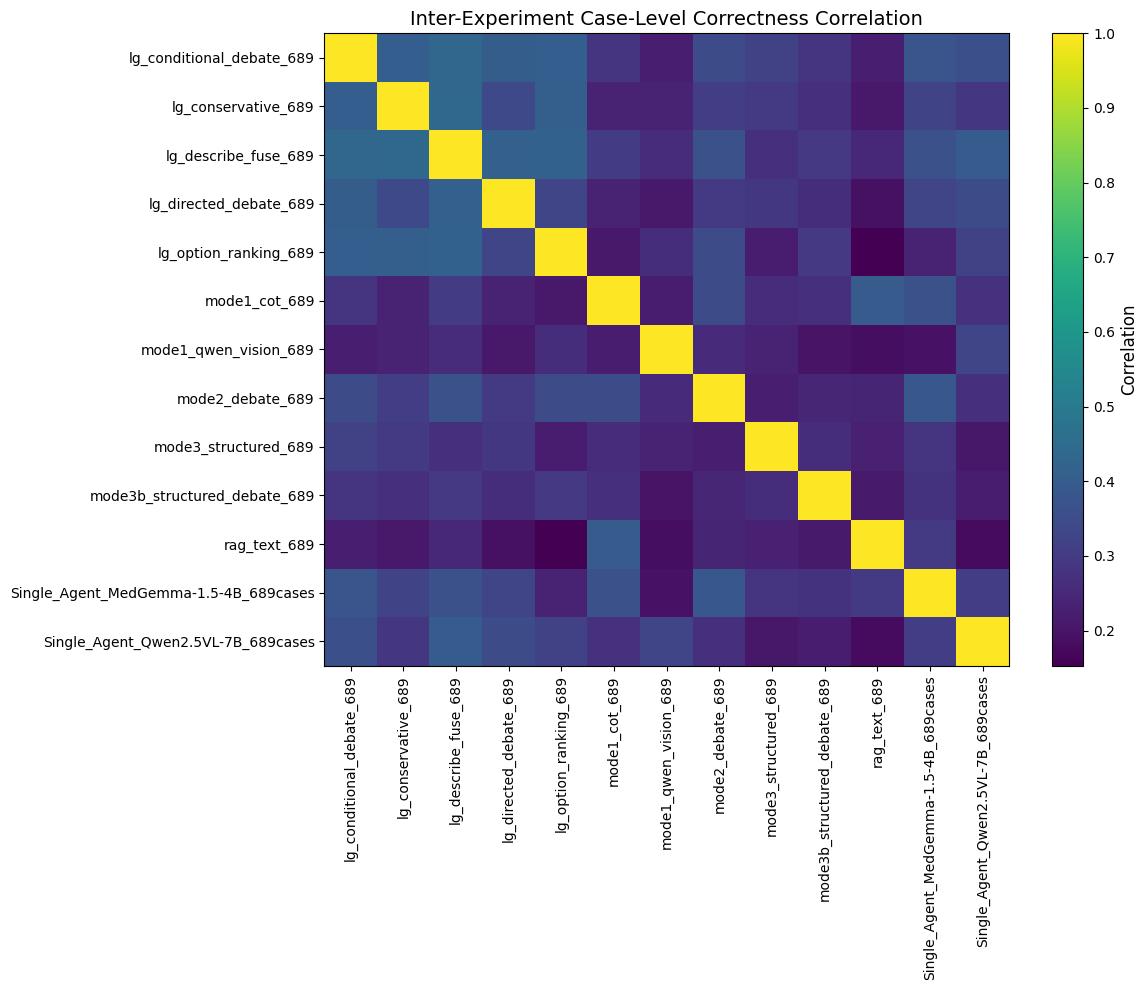

In [7]:
exp_corr_path = OUTPUT_DIR / "analysis_experiment_correlation.csv"

if exp_corr_path.exists():
    exp_corr = pd.read_csv(exp_corr_path, index_col=0)
    display(exp_corr)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(exp_corr.values, aspect="auto")
    ax.set_xticks(range(len(exp_corr.columns)))
    ax.set_xticklabels(exp_corr.columns, rotation=90)
    ax.set_yticks(range(len(exp_corr.index)))
    ax.set_yticklabels(exp_corr.index)
    ax.set_title("Inter-Experiment Case-Level Correctness Correlation")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Correlation")
    save_fig("experiment_correlation_heatmap.png")
else:
    print("Experiment correlation CSV not found.")


## 6. Agreement-conditioned accuracy

This compares final accuracy when text and vision agents initially agree vs disagree.


,experiment,agree_n,agree_accuracy,disagree_n,disagree_accuracy,agreement_rate
0,lg_conditional_debate_689,126,50.00,563,51.15,18.3
1,lg_option_ranking_689,102,60.78,587,49.06,14.8
2,mode1_cot_689,246,58.13,443,31.38,35.7
3,mode1_qwen_vision_689,197,56.85,492,33.13,28.6
4,mode3_structured_689,214,57.48,472,39.19,31.2
5,rag_text_689,217,51.61,472,30.30,31.5


Saved: thesis_figures\agreement_conditioned_accuracy.png


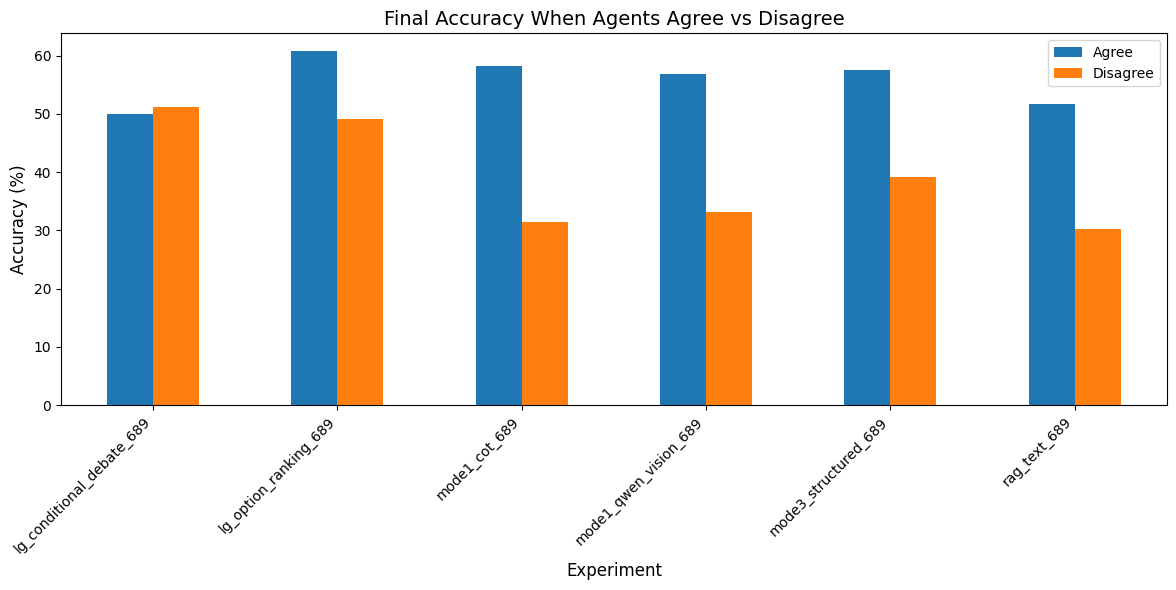

Saved: thesis_figures\agreement_rate.png


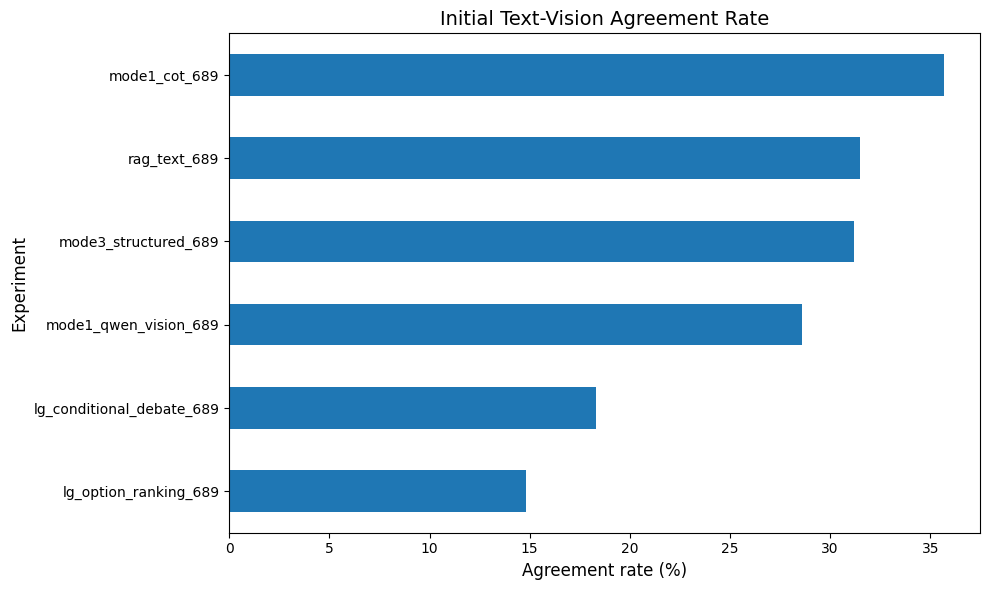

In [8]:
agreement_path = OUTPUT_DIR / "analysis_agreement_conditioned.csv"

if agreement_path.exists():
    agreement = pd.read_csv(agreement_path)
    display(agreement)

    plot_df = agreement.set_index("experiment")[["agree_accuracy", "disagree_accuracy"]]
    ax = plot_df.plot(kind="bar", figsize=(12, 6))
    ax.set_title("Final Accuracy When Agents Agree vs Disagree")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Accuracy (%)")
    ax.legend(["Agree", "Disagree"])
    plt.xticks(rotation=45, ha="right")
    save_fig("agreement_conditioned_accuracy.png")

    rate_df = agreement.set_index("experiment")[["agreement_rate"]].sort_values("agreement_rate")
    ax = rate_df.plot(kind="barh", legend=False, figsize=(10, 6))
    ax.set_title("Initial Text-Vision Agreement Rate")
    ax.set_xlabel("Agreement rate (%)")
    ax.set_ylabel("Experiment")
    save_fig("agreement_rate.png")
else:
    print("Agreement-conditioned CSV not found.")


## 7. Transition matrices

These show whether a collaboration method preserved correct initial text answers, hurt them, or rescued wrong ones.


'lg_conditional_debate_689'

,final_correct,final_wrong
text_correct,281,48
text_wrong,70,290


Saved: thesis_figures\transition_matrix_lg_conditional_debate_689.png


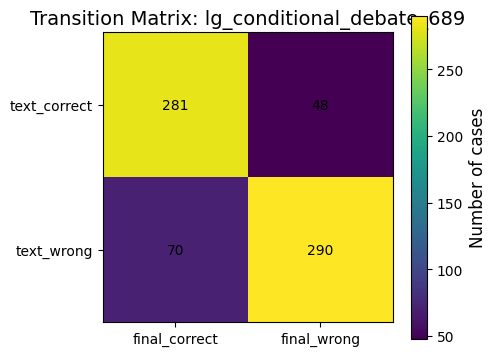

'lg_conservative_689'

,final_correct,final_wrong
text_correct,334,3
text_wrong,6,346


Saved: thesis_figures\transition_matrix_lg_conservative_689.png


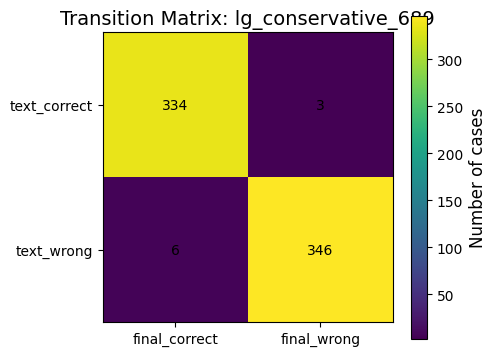

'lg_describe_fuse_689'

,final_correct,final_wrong
text_correct,272,28
text_wrong,69,320


Saved: thesis_figures\transition_matrix_lg_describe_fuse_689.png


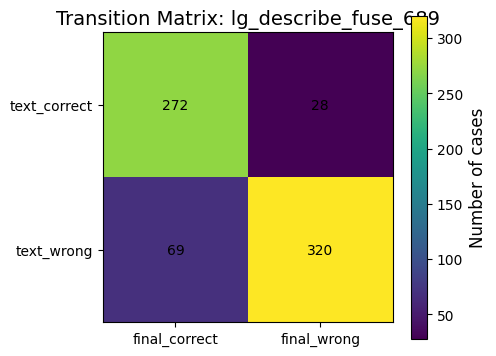

'lg_directed_debate_689'

,final_correct,final_wrong
text_correct,232,104
text_wrong,82,271


Saved: thesis_figures\transition_matrix_lg_directed_debate_689.png


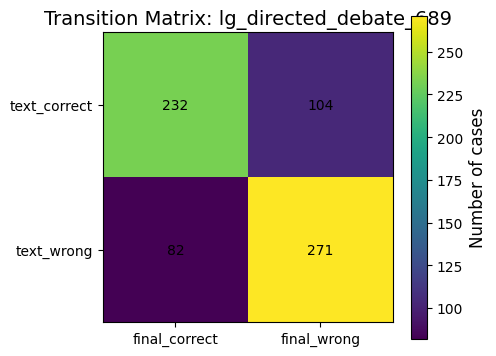

'lg_option_ranking_689'

,final_correct,final_wrong
text_correct,324,60
text_wrong,26,279


Saved: thesis_figures\transition_matrix_lg_option_ranking_689.png


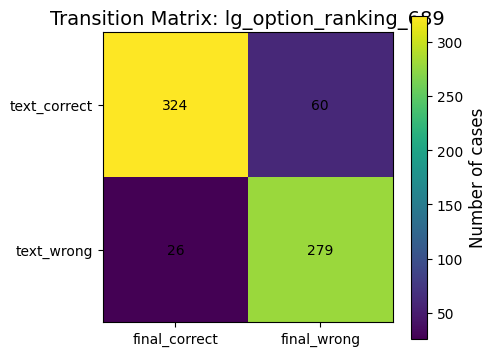

'mode1_cot_689'

,final_correct,final_wrong
text_correct,221,134
text_wrong,61,273


Saved: thesis_figures\transition_matrix_mode1_cot_689.png


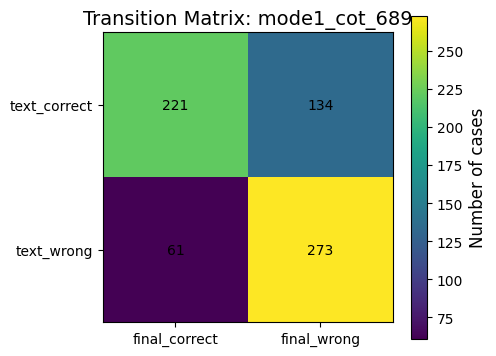

'mode1_qwen_vision_689'

,final_correct,final_wrong
text_correct,213,150
text_wrong,62,264


Saved: thesis_figures\transition_matrix_mode1_qwen_vision_689.png


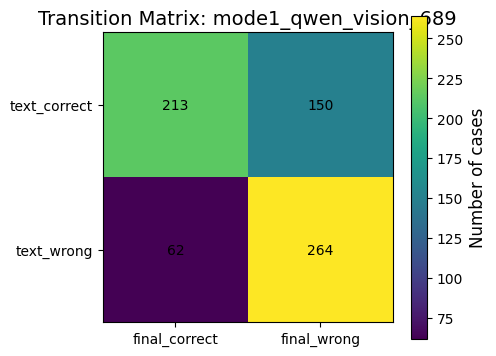

'mode3_structured_689'

,final_correct,final_wrong
text_correct,247,102
text_wrong,61,276


Saved: thesis_figures\transition_matrix_mode3_structured_689.png


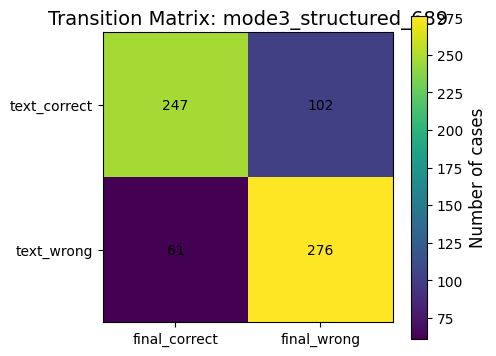

'rag_text_689'

,final_correct,final_wrong
text_correct,169,134
text_wrong,86,300


Saved: thesis_figures\transition_matrix_rag_text_689.png


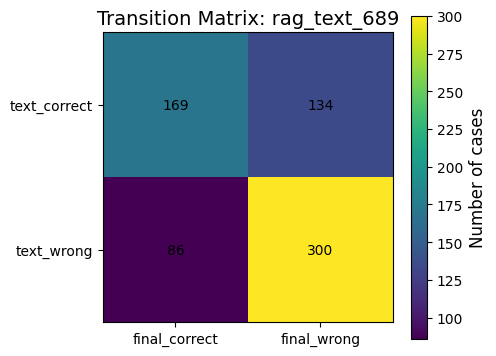

In [9]:
transition_files = sorted(OUTPUT_DIR.glob("analysis_transition_*.csv"))

for path in transition_files:
    name = path.stem.replace("analysis_transition_", "")
    mat = pd.read_csv(path, index_col=0)
    display(name, mat)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(mat.values)

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_title(f"Transition Matrix: {name}")

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, int(mat.iloc[i, j]), ha="center", va="center")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Number of cases")
    save_fig(f"transition_matrix_{name}.png")


## 8. Calibration curves

These show whether higher model confidence actually corresponds to higher accuracy.


'lg_conditional_debate_689'

,conf_bucket,accuracy,n_cases
0,1,58.54,82
1,2,41.86,86
2,3,51.08,278
3,4,48.34,211
4,5,71.88,32


Saved: thesis_figures\calibration_lg_conditional_debate_689.png


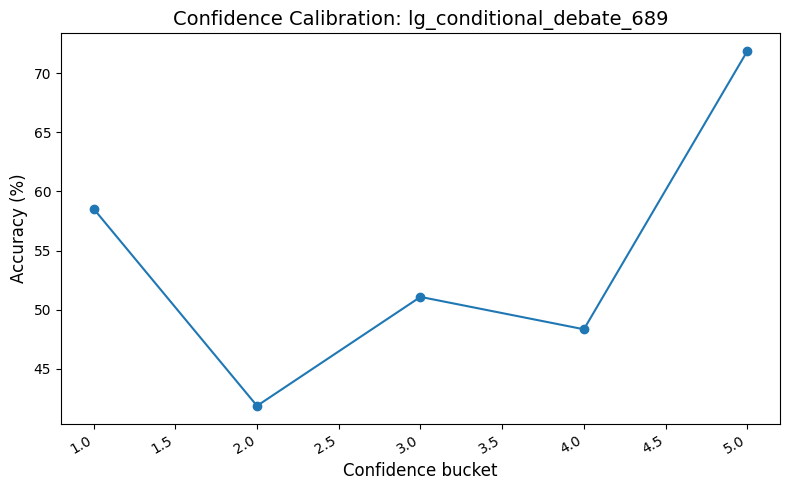

'lg_conservative_689'

,conf_bucket,accuracy,n_cases
0,1,51.60,593
1,2,0.00,2
2,3,33.33,33
3,4,0.00,4
4,5,40.35,57


Saved: thesis_figures\calibration_lg_conservative_689.png


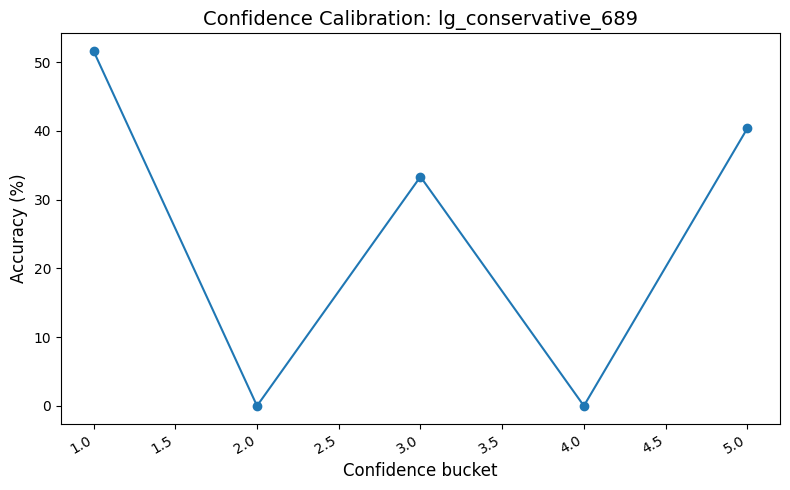

'lg_option_ranking_689'

,conf_bucket,accuracy,n_cases
0,1,50.45,111
1,2,55.56,81
2,3,51.32,189
3,4,50.56,89
4,5,48.86,219


Saved: thesis_figures\calibration_lg_option_ranking_689.png


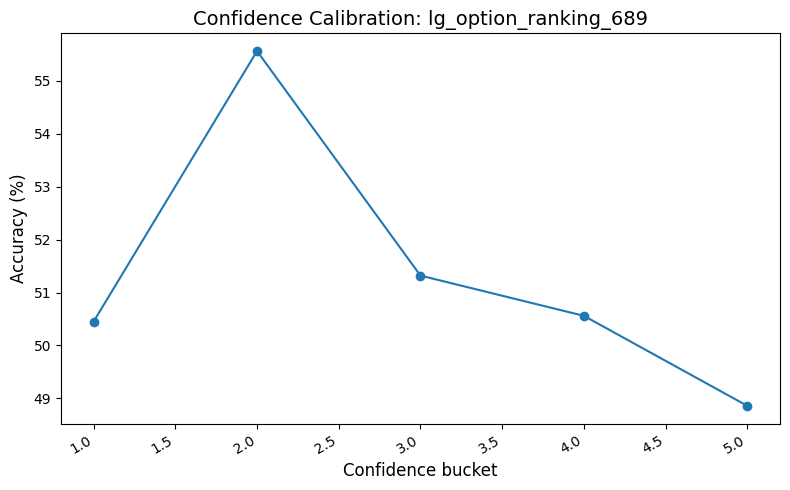

'mode3b_structured_debate_689'

,conf_bucket,accuracy,n_cases
0,<0.5,50.00,24
1,0.5-0.7,30.00,20
2,0.7-0.8,28.57,21
3,0.8-0.9,40.00,95
4,0.9-1.0,49.15,529


Saved: thesis_figures\calibration_mode3b_structured_debate_689.png


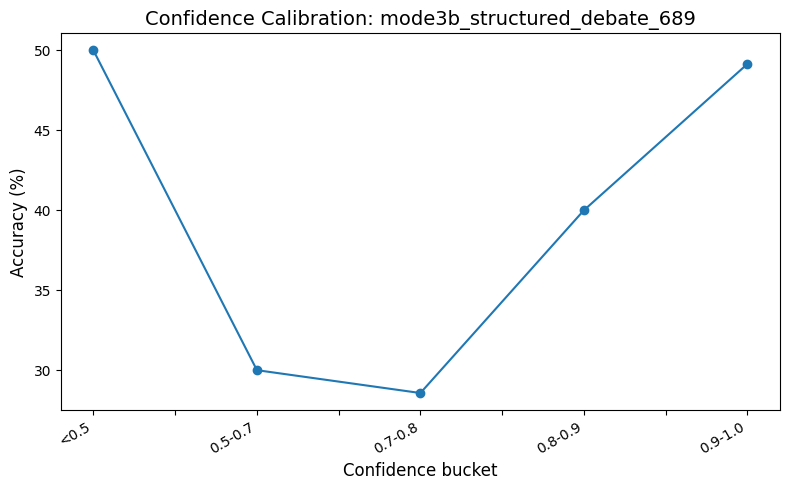

In [10]:
calibration_files = sorted(OUTPUT_DIR.glob("analysis_calibration_*.csv"))

for path in calibration_files:
    name = path.stem.replace("analysis_calibration_", "")
    cal = pd.read_csv(path)
    display(name, cal)

    ax = cal.plot(
        kind="line",
        x="conf_bucket",
        y="accuracy",
        marker="o",
        legend=False,
        figsize=(8, 5),
    )
    ax.set_title(f"Confidence Calibration: {name}")
    ax.set_xlabel("Confidence bucket")
    ax.set_ylabel("Accuracy (%)")
    plt.xticks(rotation=30, ha="right")
    save_fig(f"calibration_{name}.png")


## 9. Case consistency distribution

This shows how many experiments got each case correct. Cases with `n_correct = 0` are universally difficult; cases with high `n_correct` are consistently easy.


,lg_conditional_debate_689,lg_conservative_689,lg_describe_fuse_689,lg_directed_debate_689,lg_option_ranking_689,mode1_cot_689,mode1_qwen_vision_689,mode2_debate_689,mode3_structured_689,mode3b_structured_debate_689,rag_text_689,Single_Agent_MedGemma-1.5-4B_689cases,Single_Agent_Qwen2.5VL-7B_689cases,n_correct,pct_correct
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,7,53.8
10,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,8,61.5
100,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,9,69.2
101,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,12,92.3
102,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2,15.4


Saved: thesis_figures\case_consistency_distribution.png


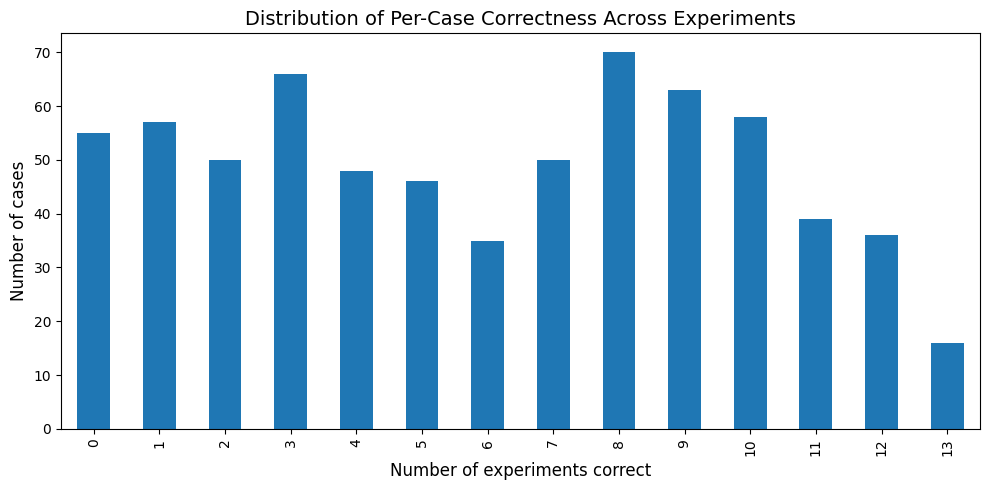

Saved hardest/easiest case lists to thesis_figures/


In [11]:
case_path = OUTPUT_DIR / "analysis_case_consistency.csv"

if case_path.exists():
    case_consistency = pd.read_csv(case_path, index_col=0)
    display(case_consistency.head())

    counts = case_consistency["n_correct"].value_counts().sort_index()
    ax = counts.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Distribution of Per-Case Correctness Across Experiments")
    ax.set_xlabel("Number of experiments correct")
    ax.set_ylabel("Number of cases")
    save_fig("case_consistency_distribution.png")

    hardest = case_consistency.sort_values("n_correct").head(20)
    easiest = case_consistency.sort_values("n_correct", ascending=False).head(20)

    hardest.to_csv(FIG_DIR / "hardest_20_cases.csv")
    easiest.to_csv(FIG_DIR / "easiest_20_cases.csv")

    print("Saved hardest/easiest case lists to thesis_figures/")
else:
    print("Case consistency CSV not found.")
